# Train Route CVAE

This notebook launches training for the route conditional VAE using the existing training pipeline in the project.

## Colab setup (clone repo first)

If you run this notebook on a Google Colab kernel, run the next cell to clone the repo and set `PROJECT_ROOT`.

- Set `REPO_SLUG` to your GitHub repo (`owner/repo`).
- For private repos, provide a PAT with at least read access to repo contents.

In [1]:
import os
import ipywidgets as widgets
from IPython.display import display

os.environ.setdefault("REPO_SLUG", "ZYCC6002/Just-Go-Up-AI")

# create widget to load file into notebook kernel
widgets.FileUpload(
    accept='.env',  # .env file with 1 environment variable per line
    multiple=False  # True to accept multiple files upload else False
)

uploader = widgets.FileUpload()
display(uploader)

FileUpload(value={}, description='Upload')

In [2]:
filename_dict_key = list(uploader.value)[0]
env_content_string = uploader.value[filename_dict_key]['content'].decode('utf-8')

# splits each lines on the first '='
# and converts them into actual environment variables
for line in env_content_string.splitlines():
    if '=' in line and line.strip() and not line.strip().startswith('#'):
        key, value = line.split('=', 1)
        key = key.strip()
        value = value.strip().strip("'").strip('"')
        os.environ[key] = value

In [3]:
import os

# Set these in the Colab runtime before running the clone cell.
# Do not hardcode secrets into the notebook file.
REPO_SLUG = os.environ.get("REPO_SLUG", "").strip()
GITHUB_TOKEN = os.environ.get("GITHUB_TOKEN", "").strip()

if REPO_SLUG:
    print(f"REPO_SLUG set to: {REPO_SLUG}")
else:
    print("REPO_SLUG is not set yet.")

if GITHUB_TOKEN:
    print("GITHUB_TOKEN is already set in the runtime.")
else:
    print("GITHUB_TOKEN is not set yet.")

REPO_SLUG set to: ZYCC6002/Just-Go-Up-AI
GITHUB_TOKEN is already set in the runtime.


In [4]:
from pathlib import Path
import os
import sys
import subprocess

# Be strict to avoid false positives outside real Colab runtime
IN_COLAB = ("google.colab" in sys.modules) and Path("/content").exists()

REPO_SLUG = os.environ.get("REPO_SLUG", "").strip()
COLAB_REPO_DIR = Path("/content/JustGoUpAI")

def _build_git_auth_env_and_cleanup(token: str):
    """Return (env, cleanup_fn) for non-interactive authenticated git over HTTPS."""
    env = os.environ.copy()
    env["GIT_TERMINAL_PROMPT"] = "0"
    askpass_path = None

    if token:
        askpass_path = Path("/tmp/git_askpass.sh")
        askpass_path.write_text(
            "#!/bin/sh\n"
            "case \"$1\" in\n"
            "  *Username*) echo \"x-access-token\" ;;\n"
            "  *Password*) echo \"$GITHUB_TOKEN\" ;;\n"
            "  *) echo \"\" ;;\n"
            "esac\n"
        )
        askpass_path.chmod(0o700)
        env["GITHUB_TOKEN"] = token
        env["GIT_ASKPASS"] = str(askpass_path)

    def _cleanup():
        if askpass_path is not None:
            askpass_path.unlink(missing_ok=True)
        env.pop("GITHUB_TOKEN", None)

    return env, _cleanup

def _run_git(cmd, repo_dir, env):
    return subprocess.run(
        cmd,
        cwd=str(repo_dir),
        check=True,
        timeout=90,
        text=True,
        capture_output=True,
        env=env,
    )

def run_git_pull(repo_dir, token: str):
    print(f"Updating repo in {repo_dir}...")
    env, cleanup = _build_git_auth_env_and_cleanup(token)
    try:
        try:
            # Fast-forward only avoids accidental merge commits in notebooks/ephemeral envs.
            _run_git(["git", "pull", "--ff-only"], repo_dir, env)
            print("Repo updated with fast-forward pull.")
            return True
        except subprocess.CalledProcessError as e_ff:
            print("Fast-forward pull failed.")
            if e_ff.stderr:
                print(e_ff.stderr.strip())

        try:
            # Fallback: rebase + autostash handles local drift safely in most cases.
            _run_git(["git", "pull", "--rebase", "--autostash"], repo_dir, env)
            print("Repo updated with rebase/autostash pull.")
            return True
        except subprocess.CalledProcessError as e_rb:
            print("Rebase pull also failed; keeping existing checkout and continuing.")
            if e_rb.stderr:
                print(e_rb.stderr.strip())
            print(
                "Tip: If this persists, open a terminal in Colab and run: "
                "git status && git branch --show-current && git remote -v"
            )
            return False
        except Exception as e:
            print(f"Unexpected git pull error: {e}")
            return False
    finally:
        cleanup()

if IN_COLAB:
    token = os.environ.get("GITHUB_TOKEN", "").strip()

    if COLAB_REPO_DIR.exists():
        print(f"Repo already exists at {COLAB_REPO_DIR}")
        if token:
            print("Using GitHub token from GITHUB_TOKEN env for git pull.")
        else:
            print("No GITHUB_TOKEN set. Pull will only work for public repos.")
        run_git_pull(COLAB_REPO_DIR, token)
    else:
        if not REPO_SLUG:
            raise RuntimeError("Set REPO_SLUG before running the clone cell.")

        clone_url = f"https://github.com/{REPO_SLUG}.git"
        env, cleanup = _build_git_auth_env_and_cleanup(token)

        if token:
            print("Using GitHub token from GITHUB_TOKEN env.")
        else:
            print("No GITHUB_TOKEN set. Attempting anonymous clone (public repos only).")
            print("If this is a private repo, set GITHUB_TOKEN in the Colab runtime and rerun this cell.")

        try:
            subprocess.run(
                ["git", "clone", clone_url, str(COLAB_REPO_DIR)],
                check=True,
                env=env,
                timeout=180,
            )
        except subprocess.CalledProcessError as e:
            raise RuntimeError(
                "git clone failed. Check REPO_SLUG and, for private repos, set GITHUB_TOKEN in the runtime first."
            ) from e
        except subprocess.TimeoutExpired as e:
            raise RuntimeError(
                "git command timed out. Check network connectivity in Colab and rerun."
            ) from e
        finally:
            cleanup()

        print(f"Cloned repo to {COLAB_REPO_DIR}")

    os.environ["PROJECT_ROOT"] = str(COLAB_REPO_DIR)
    print(f"PROJECT_ROOT set to: {os.environ['PROJECT_ROOT']}")
else:
    print("Not running on Colab; skipping clone step.")

Using GitHub token from GITHUB_TOKEN env.
Cloned repo to /content/JustGoUpAI
PROJECT_ROOT set to: /content/JustGoUpAI


## Project root & import path

Locates the repository root (works locally and on Colab) and adds `src/` to `sys.path` so the training modules are importable.

In [5]:
from pathlib import Path
import os
import sys
import shlex
import subprocess

IN_COLAB = "google.colab" in sys.modules

def is_project_root(p: Path) -> bool:
    return (p / "src/model_training/train_route_cvae.py").exists() and (p / "pyproject.toml").exists()

def find_project_root(start: Path) -> Path:
    candidates = [start, *start.parents]

    # Local workspace fallback
    candidates.append(Path("/Users/christopherchan/Documents/Coding Projects/2026/JustGoUpAI"))

    # Optional env override
    env_root = os.environ.get("PROJECT_ROOT")
    if env_root:
        env_path = Path(env_root).expanduser().resolve()
        candidates.extend([env_path, *env_path.parents])

    # PWD env fallback
    pwd_env = os.environ.get("PWD")
    if pwd_env:
        pwd_path = Path(pwd_env).resolve()
        candidates.extend([pwd_path, *pwd_path.parents])

    # Colab common locations
    if IN_COLAB:
        candidates.extend(
            [
                Path("/content/JustGoUpAI"),
                Path("/content/drive/MyDrive/JustGoUpAI"),
            ]
        )

    seen = set()
    uniq_candidates = []
    for c in candidates:
        c = c.resolve()
        if c not in seen:
            seen.add(c)
            uniq_candidates.append(c)

    for p in uniq_candidates:
        if is_project_root(p):
            return p

    raise FileNotFoundError(
        "Could not locate project root. "
        f"CWD={start}. "
        "If running on Colab, clone/copy the repo under /content and set os.environ['PROJECT_ROOT']."
    )

PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_ROOT = PROJECT_ROOT / "src"

if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

print(f"Running on Colab: {IN_COLAB}")
print(f"CWD: {Path.cwd().resolve()}")
print(f"PWD env: {os.environ.get('PWD', '<none>')}")
print(f"Project root: {PROJECT_ROOT}")
print(f"Src root: {SRC_ROOT}")
print(f"Training script exists: {(PROJECT_ROOT / 'src/model_training/train_route_cvae.py').exists()}")

Running on Colab: True
CWD: /content
PWD env: /
Project root: /content/JustGoUpAI
Src root: /content/JustGoUpAI/src
Training script exists: True


## Data root

On Colab, mounts Google Drive and points `DATA_ROOT` at the folder containing the Kilter database. Locally, defaults to `<project>/data/`.

In [6]:
from pathlib import Path
import os

# In Colab, mount Google Drive and point DATA_ROOT at your Kilter_data folder.
if IN_COLAB:
    try:
        from google.colab import drive
        drive.mount("/content/drive")
        DATA_ROOT = Path(os.environ.get("DATA_ROOT", "/content/drive/MyDrive/Kilter_data"))
    except Exception as e:
        raise RuntimeError(
            "Google Drive mount failed in Colab. "
            "Make sure you are running in a Colab runtime and have authorized Drive access. "
            "If your data is elsewhere in Drive, set DATA_ROOT to that folder path before running this cell."
        ) from e
else:
    DATA_ROOT = Path(os.environ.get("DATA_ROOT", PROJECT_ROOT / "data"))

print(f"DATA_ROOT: {DATA_ROOT}")
print(f"DB exists: {(DATA_ROOT / "raw/kilter_database.sqlite").exists()}")

Mounted at /content/drive
DATA_ROOT: /content/drive/MyDrive/Kilter_data
DB exists: True


## Hardware check

Confirms PyTorch can see a GPU (CUDA or MPS). Training will still run on CPU but will be much slower.

In [7]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU count: {torch.cuda.device_count()}")
    print(f"GPU name: {torch.cuda.get_device_name(0)}")
print(f"MPS available (Apple): {torch.backends.mps.is_available()}")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU count: 1
GPU name: Tesla T4
MPS available (Apple): False


## Training configuration

Adjust values below, then run the next cells.

In [11]:
train_cfg = {
    "db_path": DATA_ROOT / "raw/kilter_database.sqlite",
    "cache_path": DATA_ROOT / "preprocessed_routes_cache.pt",
    "checkpoint_path": DATA_ROOT / "route_cvae.pt",
    "loss_plot_path": DATA_ROOT / "route_cvae_loss_curve.png",

    # Data sampling / filtering
    "max_routes": 1000000,
    "min_holds": 1,
    "require_full_metadata": False,

    # Optimization
    "epochs": 100,
    "batch_size": 32,
    "lr": 2e-4,
    "weight_decay": 1e-4,
    "latent_dim": 16,
    "numeric_weight": 0.25,
    "kl_beta": 0.5,
    "kl_warmup_epochs": 0,
    "grad_clip_norm": 1.0,
    "seed": 42,

    # Encoder architecture
    "encoder_d_model": 256,
    "encoder_nhead": 8,
    "encoder_num_layers": 6,
    "encoder_dim_feedforward": 1024,

    # Decoder architecture
    "decoder_d_model": 128,
    "decoder_num_layers": 4,
    "decoder_dim_feedforward": 512,

    # Conditioning
    "encoder_use_condition": True,
    "decoder_use_cond_adaln": True,
    "decoder_z_memory_tokens": 8,

    # --- Shape-only ablation experiment ---
    # Absolute x/y coordinates removed: forces spatial encoding via deltas + knn only.
    # Hold-type embedding removed from tokens and shape_desc: forces z to encode
    # geometric/movement structure (reachy vs compression) rather than hold-type mix.
    # Rebuild the preprocessed cache (rebuild_cache=True) whenever these change.
    "use_absolute_pos": False,
    "use_type_feature": False,

    # Route embedding pooling: learned query attends over hold token outputs.
    # Avoids the CLS shortcutting pathology — the model must synthesise style from
    # hold-level attention rather than transporting pre-computed shape_desc stats.
    "route_pool_mode": "attention",

    # Grade/angle adversarial disentanglement
    "grade_adversary_weight": 4.0,
    "grade_adversary_alpha": 3.0,

    # Free bits: minimum KL per latent dimension (nats).
    "free_bits": 1.0,

    # Early stopping
    "early_stop_delta": 0.01,
    "early_stop_patience": 8,

    # Resume and cache controls
    "resume": False,        # Fresh run — new feature set, incompatible with old checkpoint
    "resume_path": None,
    "rebuild_cache": False,  # Cache already built from previous shape-only run; set True if changed
}

train_cfg


{'db_path': PosixPath('/content/drive/MyDrive/Kilter_data/raw/kilter_database.sqlite'),
 'cache_path': PosixPath('/content/drive/MyDrive/Kilter_data/preprocessed_routes_cache.pt'),
 'checkpoint_path': PosixPath('/content/drive/MyDrive/Kilter_data/route_cvae.pt'),
 'loss_plot_path': PosixPath('/content/drive/MyDrive/Kilter_data/route_cvae_loss_curve.png'),
 'max_routes': 1000000,
 'min_holds': 1,
 'require_full_metadata': False,
 'epochs': 100,
 'batch_size': 32,
 'lr': 0.0002,
 'weight_decay': 0.0001,
 'latent_dim': 16,
 'numeric_weight': 0.25,
 'kl_beta': 0.5,
 'kl_warmup_epochs': 0,
 'grad_clip_norm': 1.0,
 'seed': 42,
 'encoder_d_model': 256,
 'encoder_nhead': 8,
 'encoder_num_layers': 6,
 'encoder_dim_feedforward': 1024,
 'decoder_d_model': 128,
 'decoder_num_layers': 4,
 'decoder_dim_feedforward': 512,
 'encoder_use_condition': True,
 'decoder_use_cond_adaln': True,
 'decoder_z_memory_tokens': 8,
 'use_absolute_pos': False,
 'use_type_feature': False,
 'route_pool_mode': 'attentio

## Build training command

Converts `train_cfg` into a CLI command for `train_route_cvae.py`. Run this cell after editing `train_cfg` to preview what will execute.

In [12]:
import shlex

def build_train_command(cfg: dict) -> list[str]:
    """Build the subprocess command list for train_route_cvae.py from a config dict."""
    script = PROJECT_ROOT / "src/model_training/train_route_cvae.py"
    cmd = [sys.executable, "-u", str(script)]
    cmd += ["--db-path", str(cfg["db_path"])]
    cmd += ["--cache-path", str(cfg["cache_path"])]
    cmd += ["--checkpoint-path", str(cfg["checkpoint_path"])]
    cmd += ["--loss-plot-path", str(cfg["loss_plot_path"])]
    cmd += ["--max-routes", str(cfg["max_routes"])]
    cmd += ["--min-holds", str(cfg["min_holds"])]
    cmd += ["--epochs", str(cfg["epochs"])]
    cmd += ["--batch-size", str(cfg["batch_size"])]
    cmd += ["--lr", str(cfg["lr"])]
    cmd += ["--weight-decay", str(cfg["weight_decay"])]
    cmd += ["--latent-dim", str(cfg["latent_dim"])]
    cmd += ["--numeric-weight", str(cfg["numeric_weight"])]
    cmd += ["--kl-beta", str(cfg["kl_beta"])]
    cmd += ["--grad-clip-norm", str(cfg["grad_clip_norm"])]
    cmd += ["--seed", str(cfg["seed"])]

    if cfg.get("require_full_metadata"):
        cmd += ["--require-full-metadata"]
    if cfg.get("resume"):
        cmd += ["--resume"]
    if cfg.get("resume_path"):
        cmd += ["--resume-path", str(cfg["resume_path"])]
    if cfg.get("rebuild_cache"):
        cmd += ["--rebuild-cache"]
    if cfg.get("kl_warmup_epochs") is not None:
        cmd += ["--kl-warmup-epochs", str(cfg["kl_warmup_epochs"])]
    if cfg.get("early_stop_delta") is not None:
        cmd += ["--early-stop-delta", str(cfg["early_stop_delta"])]
    if cfg.get("early_stop_patience") is not None:
        cmd += ["--early-stop-patience", str(cfg["early_stop_patience"])]

    # Encoder architecture
    cmd += ["--encoder-d-model", str(cfg.get("encoder_d_model", 256))]
    cmd += ["--encoder-nhead", str(cfg.get("encoder_nhead", 8))]
    cmd += ["--encoder-num-layers", str(cfg.get("encoder_num_layers", 6))]
    cmd += ["--encoder-dim-feedforward", str(cfg.get("encoder_dim_feedforward", 1024))]

    # Decoder architecture
    cmd += ["--decoder-d-model", str(cfg.get("decoder_d_model", 128))]
    cmd += ["--decoder-num-layers", str(cfg.get("decoder_num_layers", 4))]
    cmd += ["--decoder-dim-feedforward", str(cfg.get("decoder_dim_feedforward", 512))]

    if cfg.get("encoder_use_condition", True):
        cmd += ["--encoder-use-condition"]
    else:
        cmd += ["--no-encoder-use-condition"]

    if cfg.get("encoder_use_cond_adaln", True):
        cmd += ["--encoder-use-cond-adaln"]
    else:
        cmd += ["--no-encoder-use-cond-adaln"]

    if cfg.get("decoder_use_cond_adaln", True):
        cmd += ["--decoder-use-cond-adaln"]
    else:
        cmd += ["--no-decoder-use-cond-adaln"]

    cmd += ["--decoder-z-memory-tokens", str(cfg.get("decoder_z_memory_tokens", 4))]

    # Ablation flags
    if cfg.get("use_absolute_pos", True):
        cmd += ["--use-absolute-pos"]
    else:
        cmd += ["--no-use-absolute-pos"]

    if cfg.get("use_type_feature", True):
        cmd += ["--use-type-feature"]
    else:
        cmd += ["--no-use-type-feature"]

    # Route embedding pooling mode
    cmd += ["--route-pool-mode", cfg.get("route_pool_mode", "cls")]

    adv_weight = cfg.get("grade_adversary_weight", 0.0)
    if adv_weight > 0.0:
        cmd += ["--grade-adversary-weight", str(adv_weight)]
        cmd += ["--grade-adversary-alpha", str(cfg.get("grade_adversary_alpha", 1.0))]

    free_bits = cfg.get("free_bits", 0.0)
    if free_bits > 0.0:
        cmd += ["--free-bits", str(free_bits)]

    return cmd


# Build main training command and display it
cmd = build_train_command(train_cfg)
print("Training command:")
print(" \n".join(shlex.quote(x) for x in cmd))


Training command:
/usr/bin/python3 
-u 
/content/JustGoUpAI/src/model_training/train_route_cvae.py 
--db-path 
/content/drive/MyDrive/Kilter_data/raw/kilter_database.sqlite 
--cache-path 
/content/drive/MyDrive/Kilter_data/preprocessed_routes_cache.pt 
--checkpoint-path 
/content/drive/MyDrive/Kilter_data/route_cvae.pt 
--loss-plot-path 
/content/drive/MyDrive/Kilter_data/route_cvae_loss_curve.png 
--max-routes 
1000000 
--min-holds 
1 
--epochs 
100 
--batch-size 
32 
--lr 
0.0002 
--weight-decay 
0.0001 
--latent-dim 
16 
--numeric-weight 
0.25 
--kl-beta 
0.5 
--grad-clip-norm 
1.0 
--seed 
42 
--kl-warmup-epochs 
0 
--early-stop-delta 
0.01 
--early-stop-patience 
8 
--encoder-d-model 
256 
--encoder-nhead 
8 
--encoder-num-layers 
6 
--encoder-dim-feedforward 
1024 
--decoder-d-model 
128 
--decoder-num-layers 
4 
--decoder-dim-feedforward 
512 
--encoder-use-condition 
--encoder-use-cond-adaln 
--decoder-use-cond-adaln 
--decoder-z-memory-tokens 
8 
--no-use-absolute-pos 
--no-us

## Run training

Launches the training process and streams epoch logs live. The best checkpoint (lowest validation loss) is saved to `checkpoint_path` automatically.

In [13]:
import os
import subprocess

# Run training (prints epoch logs in notebook output)
env = os.environ.copy()
env["PYTHONUNBUFFERED"] = "1"

proc = subprocess.Popen(
    cmd,
    cwd=str(PROJECT_ROOT),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    env=env,
)

assert proc.stdout is not None
for line in iter(proc.stdout.readline, ""):
    if not line:
        break
    print(line, end="", flush=True)

ret = proc.wait()
if ret != 0:
    raise RuntimeError(f"Training failed with exit code {ret}")

print("\nTraining complete.")

Using device: cuda
Loaded preprocessed dataset cache: /content/drive/MyDrive/Kilter_data/preprocessed_routes_cache.pt
Routes: total=4274 train=3419 val=427 test=428
shape_desc_dim=9 (auto-detected from cache)
Encoder: d_model=256 nhead=8 layers=6 ffn=1024
Decoder: d_model=128 nhead=8 layers=4 ffn=512
Total parameters: 7,262,099
Grade+angle adversary enabled (weight=4.0, alpha=3.0)
Epoch 001 | kl_beta=0.500000 train total=17.6598 recon=7.9019 kl_w=9.4722 cat=7.7906 num=0.4454 kl=15.4322(+0.0000) adv=0.0714 | val total=15.5761 recon=7.0064 kl_w=8.5698 cat=6.9089 num=0.3898 kl=17.1217(+1.1217) adv=0.0604
Saved checkpoint (val=15.5761): /content/drive/MyDrive/Kilter_data/route_cvae.pt
Epoch 002 | kl_beta=0.500000 train total=15.9214 recon=6.8540 kl_w=8.8075 cat=6.7569 num=0.3886 kl=15.7351(+0.0000) adv=0.0650 | val total=14.8829 recon=6.5597 kl_w=8.3233 cat=6.4676 num=0.3683 kl=16.5744(+0.5744) adv=0.0603
Saved checkpoint (val=14.8829): /content/drive/MyDrive/Kilter_data/route_cvae.pt
Epoc

## Verify artifacts

Confirms the checkpoint, loss curve, and cache files were written successfully after training.

In [14]:
artifacts = [
    train_cfg["checkpoint_path"],
    train_cfg["loss_plot_path"],
    train_cfg["cache_path"],
]

for p in artifacts:
    p = Path(p)
    print(f"{p}: {'exists' if p.exists() else 'missing'}")

/content/drive/MyDrive/Kilter_data/route_cvae.pt: exists
/content/drive/MyDrive/Kilter_data/route_cvae_loss_curve.png: exists
/content/drive/MyDrive/Kilter_data/preprocessed_routes_cache.pt: exists


## Training loss curve

Displays the loss curve saved during training. The three panels show total loss, reconstruction loss, and KL divergence across epochs for train and validation splits.

Loss curve path: /content/drive/MyDrive/Kilter_data/route_cvae_loss_curve.png


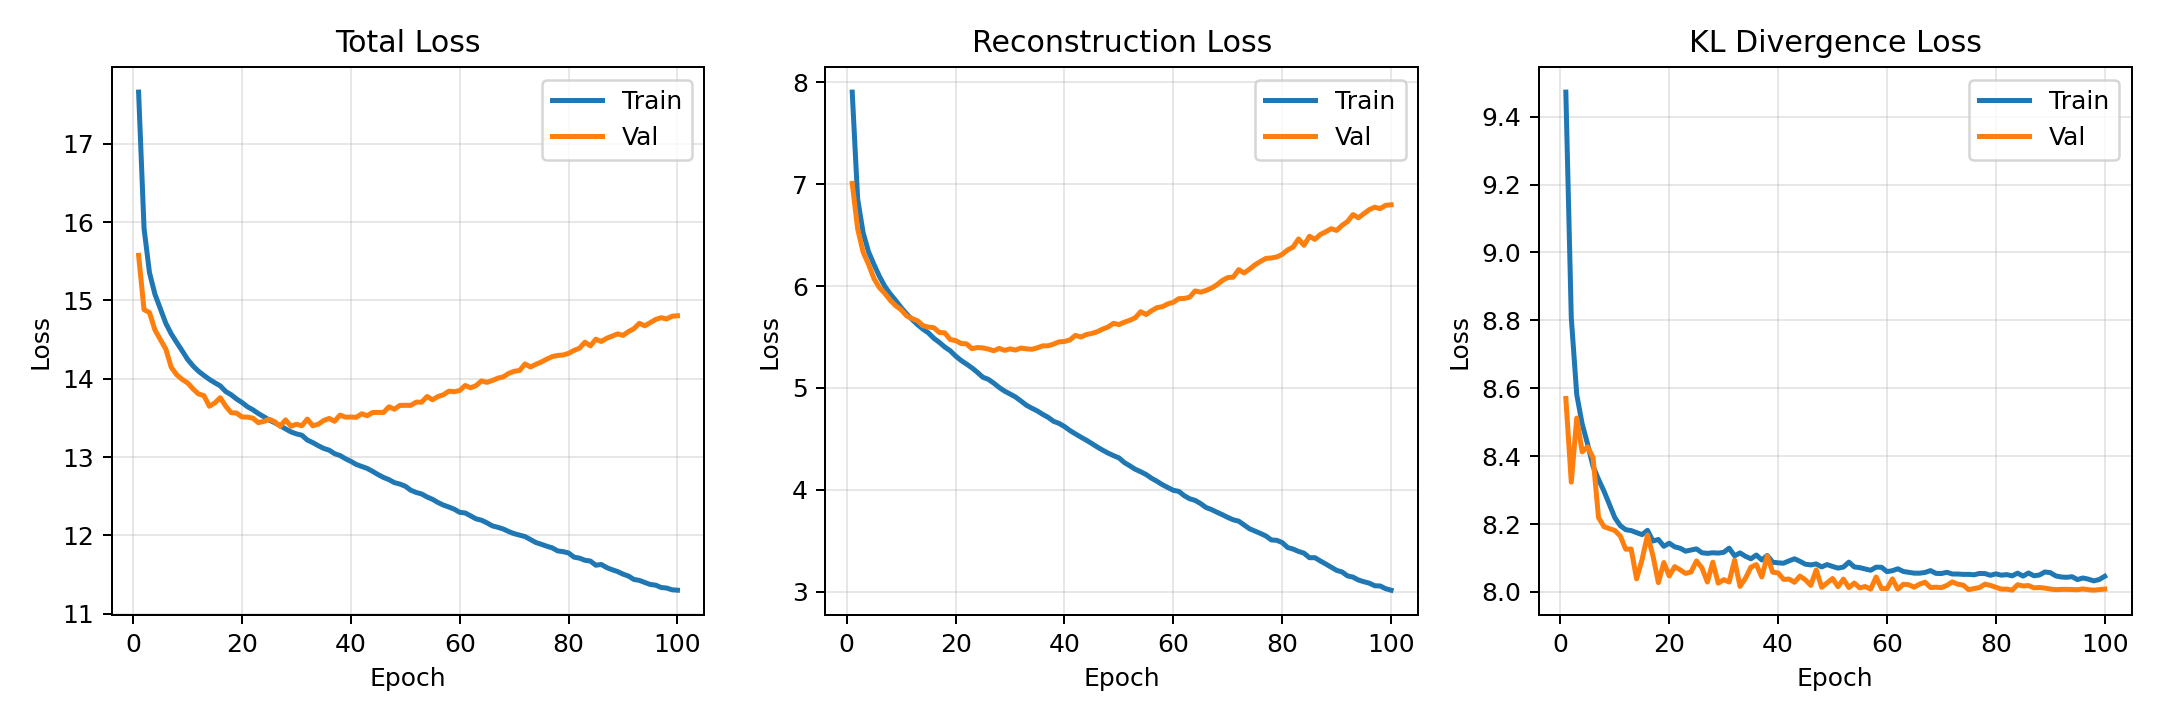

In [15]:
from pathlib import Path
from IPython.display import Image, display

loss_curve_path = Path(train_cfg.get("loss_plot_path", DATA_ROOT / "route_cvae_loss_curve.png"))

print(f"Loss curve path: {loss_curve_path}")
if not loss_curve_path.exists():
    raise FileNotFoundError(f"Loss curve image not found: {loss_curve_path}")

display(Image(filename=str(loss_curve_path)))

## HDBSCAN Clustering

Extracts latent vectors from the trained checkpoint, applies UMAP pre-reduction to 5 dims, then clusters with HDBSCAN. The resulting cache is saved to `DATA_ROOT` and reused by the visualisations below.

In [16]:
# Cluster configuration — adjust if needed, then run the cells below
cluster_cfg = {
    "db_path":               DATA_ROOT / "raw/kilter_database.sqlite",
    "cache_path":            DATA_ROOT / "preprocessed_routes_cache.pt",
    "checkpoint_path":       DATA_ROOT / "route_cvae.pt",
    "cluster_cache_path":    DATA_ROOT / "routes_hdbscan_umap.pt",
    # HDBSCAN + UMAP pre-reduction
    "method":                    "hdbscan",
    "pre_reduce":                True,
    "pre_reduce_method":         "umap",
    "pre_reduce_dims":           5,
    "hdbscan_min_cluster_size":  200,
    "hdbscan_min_samples":       15,
}

cluster_cfg

{'db_path': PosixPath('/content/drive/MyDrive/Kilter_data/raw/kilter_database.sqlite'),
 'cache_path': PosixPath('/content/drive/MyDrive/Kilter_data/preprocessed_routes_cache.pt'),
 'checkpoint_path': PosixPath('/content/drive/MyDrive/Kilter_data/route_cvae.pt'),
 'cluster_cache_path': PosixPath('/content/drive/MyDrive/Kilter_data/routes_hdbscan_umap.pt'),
 'method': 'hdbscan',
 'pre_reduce': True,
 'pre_reduce_method': 'umap',
 'pre_reduce_dims': 5,
 'hdbscan_min_cluster_size': 200,
 'hdbscan_min_samples': 15}

In [17]:
import subprocess, os, sys
from pathlib import Path

cluster_script = PROJECT_ROOT / 'src/data_analysis/routes_cluster.py'
cluster_cmd = [
    sys.executable, '-u', str(cluster_script),
    '--db-path',                  str(cluster_cfg['db_path']),
    '--cache-path',               str(cluster_cfg['cache_path']),
    '--checkpoint-path',          str(cluster_cfg['checkpoint_path']),
    '--cluster-cache-path',       str(cluster_cfg['cluster_cache_path']),
    '--method',                   cluster_cfg['method'],
    '--pre-reduce-method',        cluster_cfg['pre_reduce_method'],
    '--pre-reduce-dims',          str(cluster_cfg['pre_reduce_dims']),
    '--hdbscan-min-cluster-size', str(cluster_cfg['hdbscan_min_cluster_size']),
    '--hdbscan-min-samples',      str(cluster_cfg['hdbscan_min_samples']),
]
if cluster_cfg.get('pre_reduce'):
    cluster_cmd.append('--pre-reduce')

print('Cluster command:')
print(' \\\n  '.join(cluster_cmd))
print()

env = os.environ.copy()
env['PYTHONUNBUFFERED'] = '1'

proc = subprocess.Popen(
    cluster_cmd,
    cwd=str(PROJECT_ROOT),
    stdout=subprocess.PIPE,
    stderr=subprocess.STDOUT,
    text=True,
    bufsize=1,
    env=env,
)

assert proc.stdout is not None
for line in iter(proc.stdout.readline, ''):
    if not line:
        break
    print(line, end='', flush=True)

ret = proc.wait()
if ret != 0:
    raise RuntimeError(f'Clustering failed with exit code {ret}')

print('\nClustering complete.')

Cluster command:
/usr/bin/python3 \
  -u \
  /content/JustGoUpAI/src/data_analysis/routes_cluster.py \
  --db-path \
  /content/drive/MyDrive/Kilter_data/raw/kilter_database.sqlite \
  --cache-path \
  /content/drive/MyDrive/Kilter_data/preprocessed_routes_cache.pt \
  --checkpoint-path \
  /content/drive/MyDrive/Kilter_data/route_cvae.pt \
  --cluster-cache-path \
  /content/drive/MyDrive/Kilter_data/routes_hdbscan_umap.pt \
  --method \
  hdbscan \
  --pre-reduce-method \
  umap \
  --pre-reduce-dims \
  5 \
  --hdbscan-min-cluster-size \
  200 \
  --hdbscan-min-samples \
  15 \
  --pre-reduce

Loaded preprocessed routes cache: /content/drive/MyDrive/Kilter_data/preprocessed_routes_cache.pt
Using device: cuda
Pre-reducing 16D → 5D via UMAP ...
2026-05-29 00:44:14.450488: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, i

In [18]:
import torch, numpy as np
from pathlib import Path

cache_path = Path(cluster_cfg['cluster_cache_path'])
if not cache_path.exists():
    raise FileNotFoundError(f'Cluster cache not found: {cache_path}')

payload = torch.load(cache_path, map_location='cpu', weights_only=False)
labels = np.array(payload['cluster_ids'])
unique_labels = np.unique(labels)
n_noise = int(np.sum(labels == -1))
n_clusters = int(np.sum(unique_labels >= 0))

print(f'Cluster cache : {cache_path}')
print(f'Total routes  : {len(labels)}')
print(f'Clusters      : {n_clusters}  (labels: {sorted(unique_labels[unique_labels >= 0].tolist())})')
print(f'Noise points  : {n_noise}  (label=-1)')

Cluster cache : /content/drive/MyDrive/Kilter_data/routes_hdbscan_umap.pt
Total routes  : 4274
Clusters      : 7  (labels: [0, 1, 2, 3, 4, 5, 6])
Noise points  : 138  (label=-1)


## Visualizations

PCA and UMAP projections of the HDBSCAN cluster cache. Each point is a route, coloured by cluster label. Images are saved to `DATA_ROOT` for later reference.

PCA command:
/usr/bin/python3 \
  -u \
  /content/JustGoUpAI/src/data_analysis/routes_visualize.py \
  --method \
  pca \
  --cluster-cache-path \
  /content/drive/MyDrive/Kilter_data/routes_hdbscan_umap.pt \
  --output-path \
  /content/drive/MyDrive/Kilter_data/routes_latent_pca.png \
  --disable-click-visualizer

Saved plot to: /content/drive/MyDrive/Kilter_data/routes_latent_pca.png
Explained variance: PC1=0.7940, PC2=0.1672
Saved: /content/drive/MyDrive/Kilter_data/routes_latent_pca.png


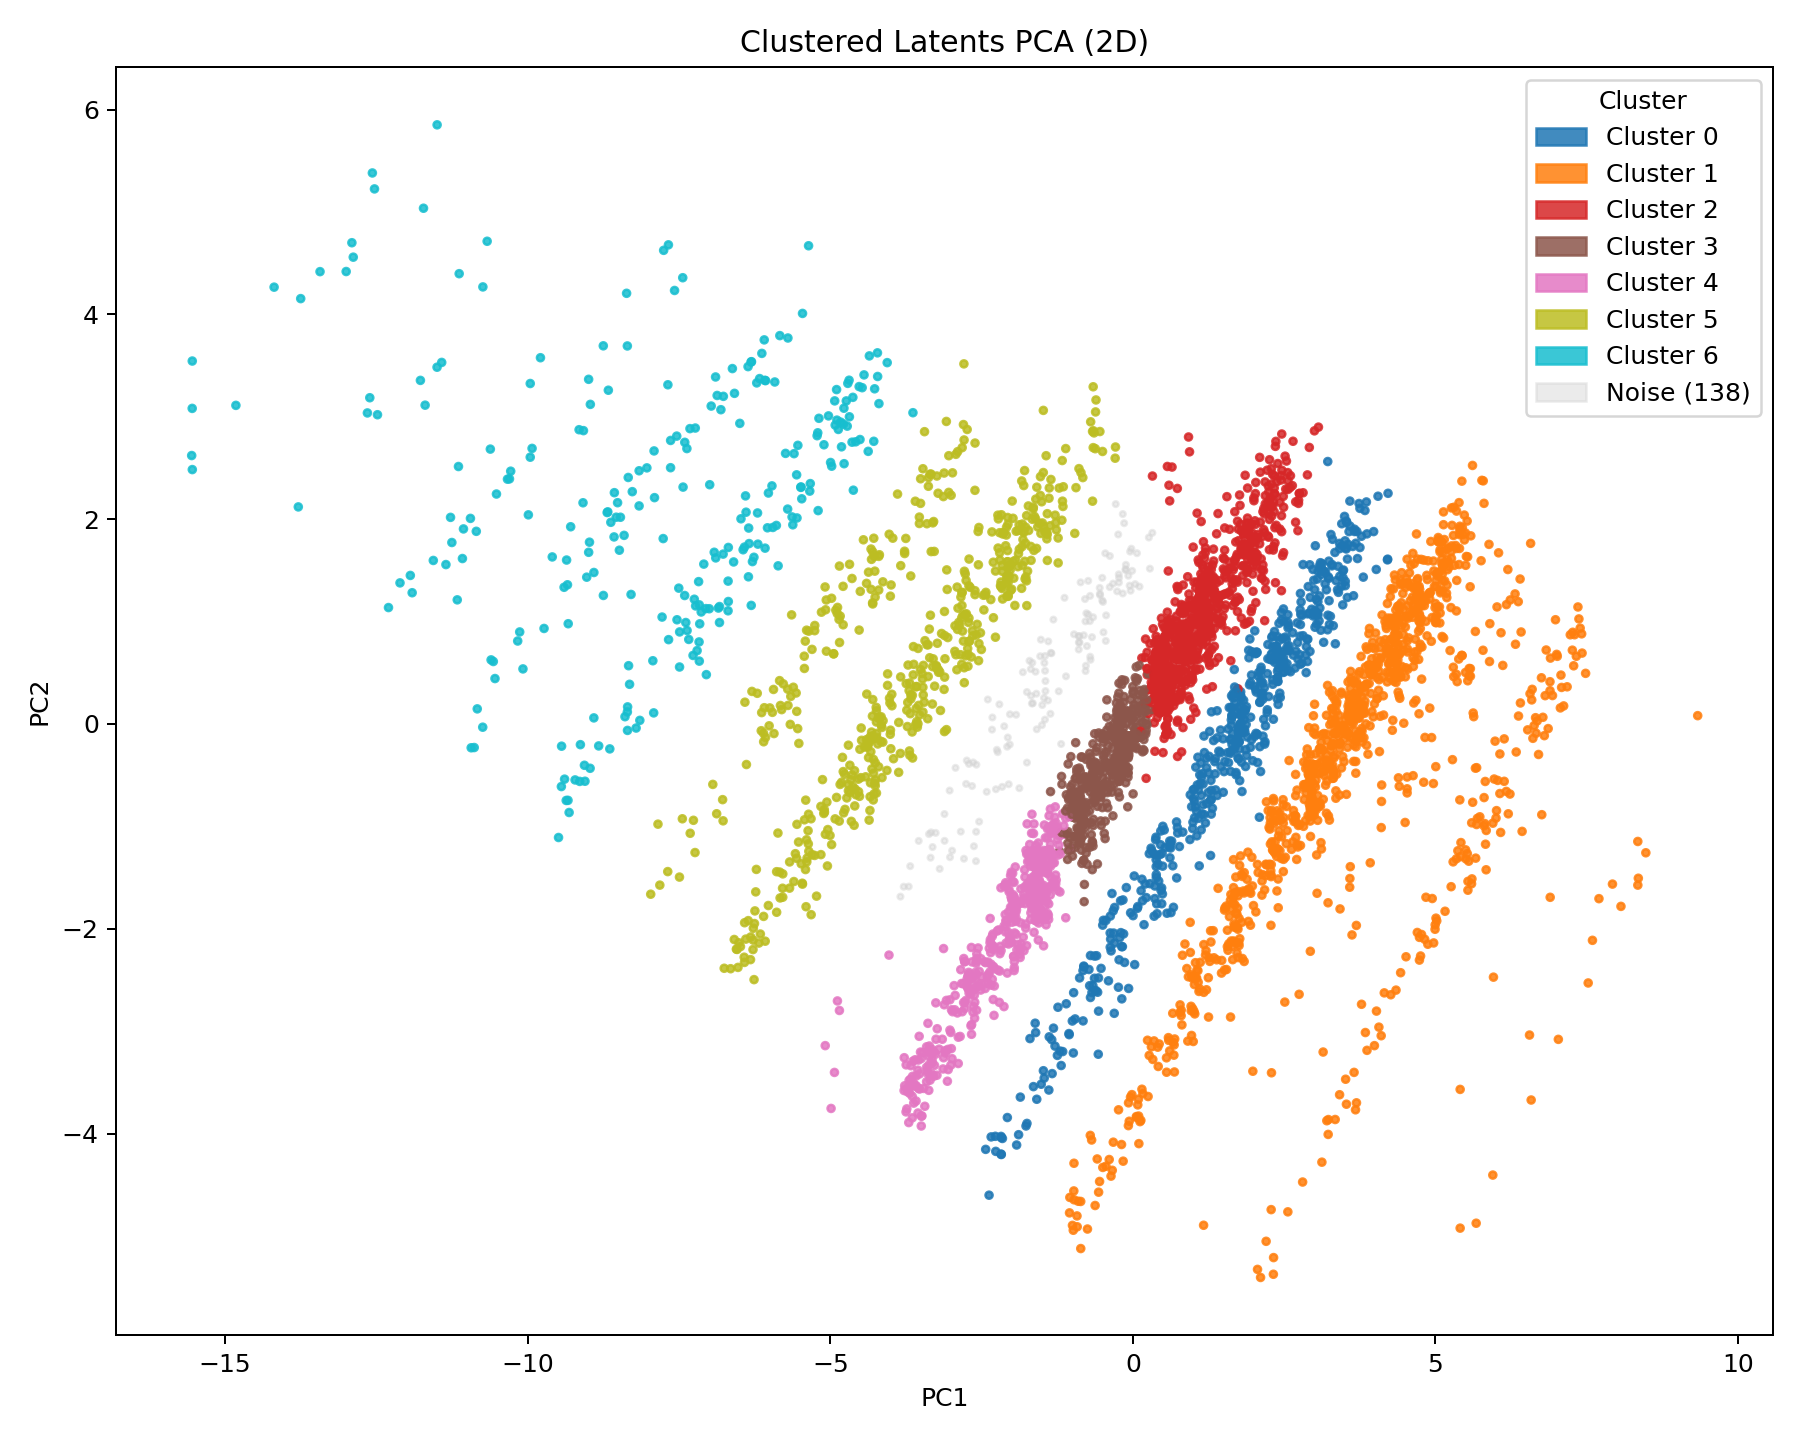

In [19]:
from IPython.display import Image, display
import subprocess, os, sys

pca_output  = DATA_ROOT / 'routes_latent_pca.png'
viz_script  = PROJECT_ROOT / 'src/data_analysis/routes_visualize.py'

viz_cmd = [
    sys.executable, '-u', str(viz_script),
    '--method',               'pca',
    '--cluster-cache-path',   str(cluster_cfg['cluster_cache_path']),
    '--output-path',          str(pca_output),
    '--disable-click-visualizer',
]

print('PCA command:')
print(' \\\n  '.join(viz_cmd))
print()

env = os.environ.copy()
env['PYTHONUNBUFFERED'] = '1'

proc = subprocess.Popen(viz_cmd, cwd=str(PROJECT_ROOT),
                        stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                        text=True, bufsize=1, env=env)
assert proc.stdout is not None
for line in iter(proc.stdout.readline, ''):
    if not line:
        break
    print(line, end='', flush=True)

ret = proc.wait()
if ret != 0:
    raise RuntimeError(f'PCA visualization failed with exit code {ret}')

print(f'Saved: {pca_output}')
display(Image(filename=str(pca_output)))

UMAP command:
/usr/bin/python3 \
  -u \
  /content/JustGoUpAI/src/data_analysis/routes_visualize.py \
  --method \
  umap \
  --cluster-cache-path \
  /content/drive/MyDrive/Kilter_data/routes_hdbscan_umap.pt \
  --output-path \
  /content/drive/MyDrive/Kilter_data/routes_latent_umap.png \
  --disable-click-visualizer

Projecting stored 5D pre-reduced embedding → 2D UMAP (anchored to clustering space).
2026-05-29 00:45:30.216279: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
Saved plot to: /content/drive/MyDrive/Kilter_data/routes_latent_umap.png
Saved: /content/drive/MyDrive/Kilte

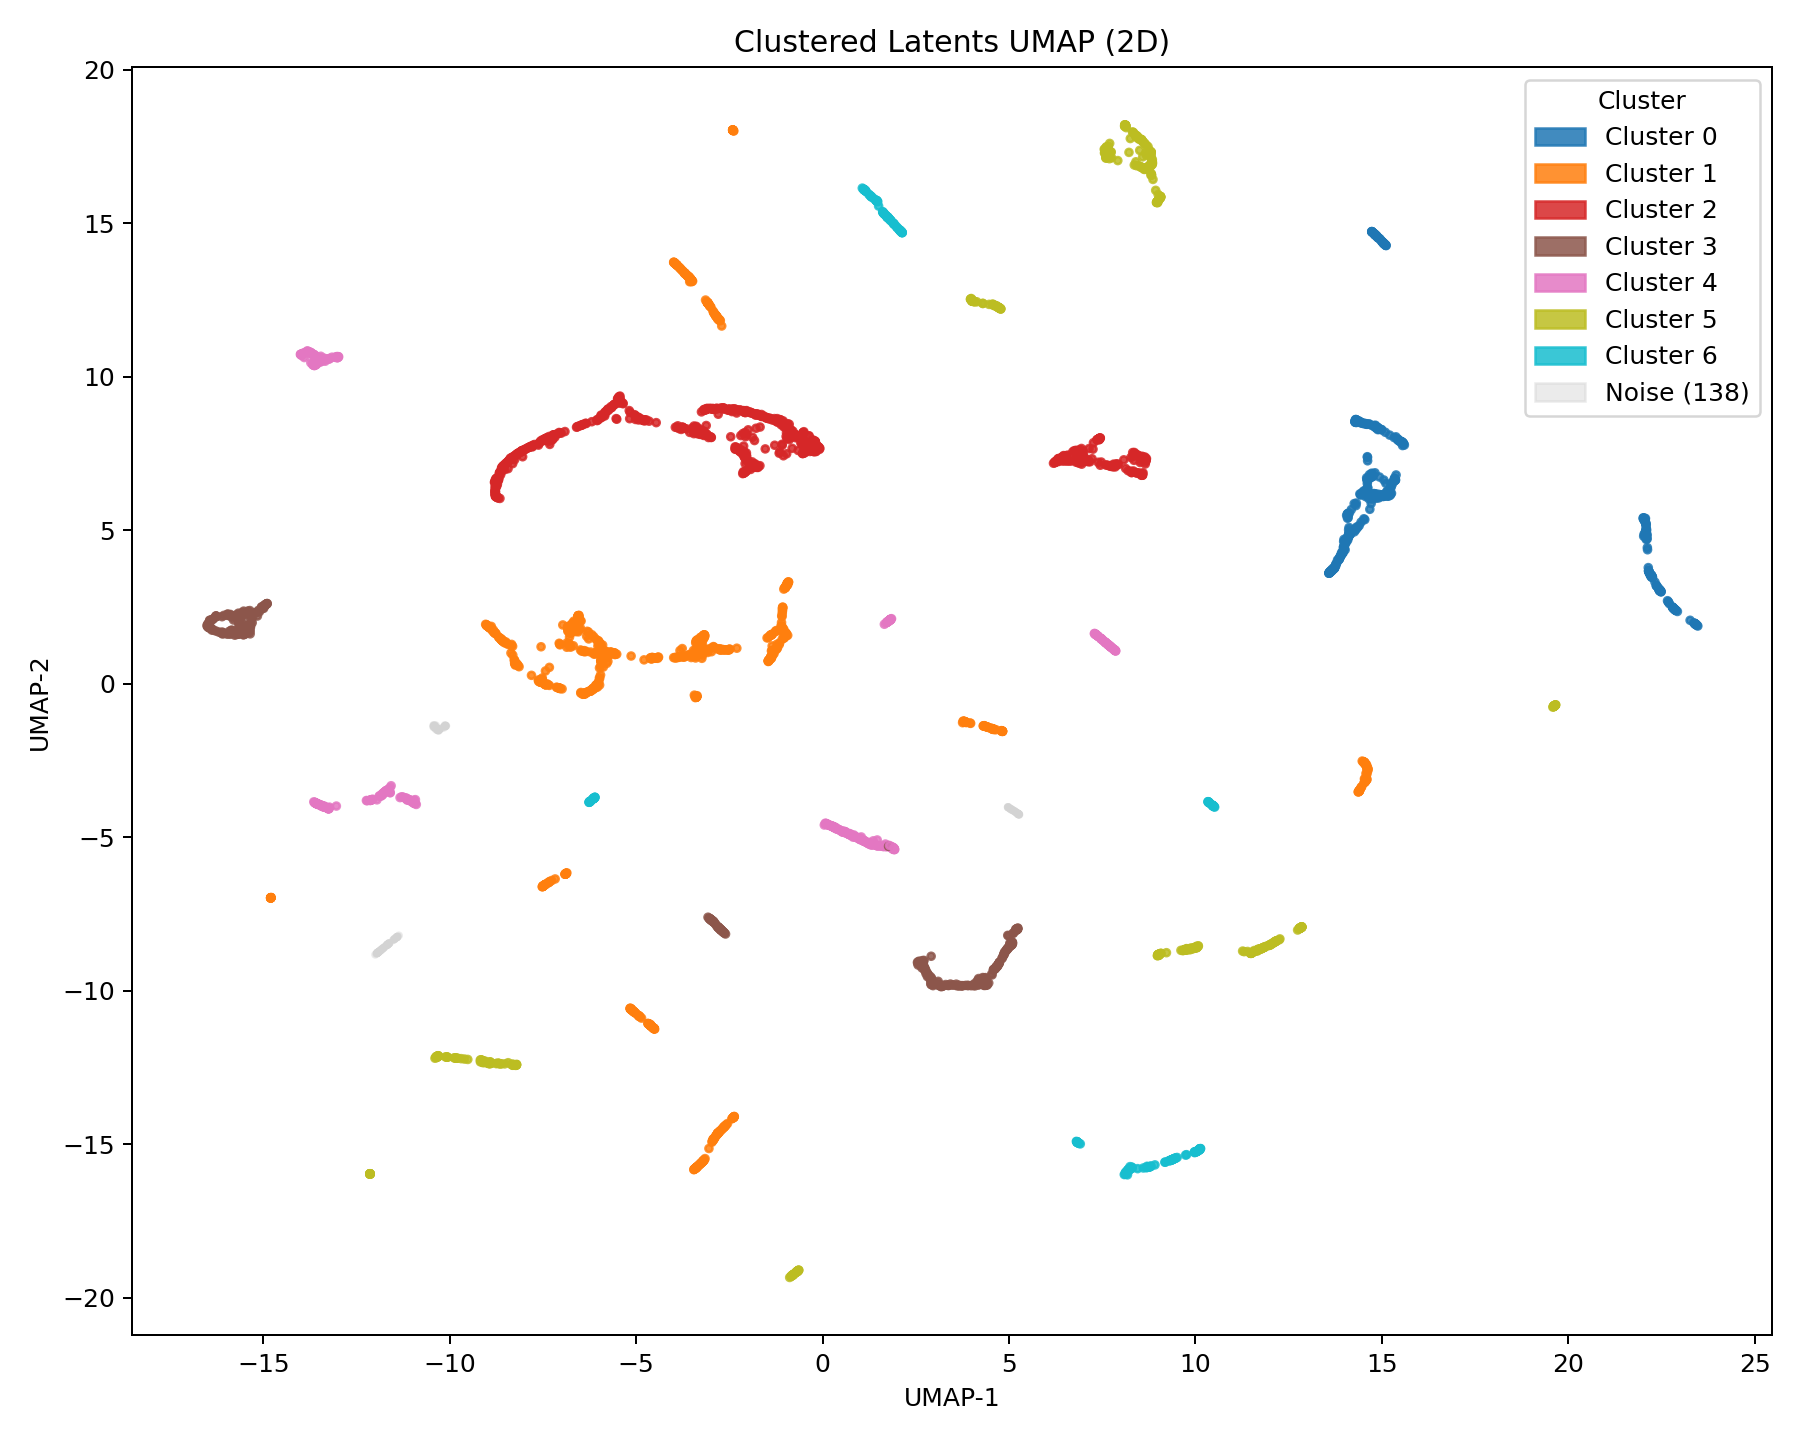

In [20]:
umap_output = DATA_ROOT / 'routes_latent_umap.png'

viz_cmd = [
    sys.executable, '-u', str(viz_script),
    '--method',               'umap',
    '--cluster-cache-path',   str(cluster_cfg['cluster_cache_path']),
    '--output-path',          str(umap_output),
    '--disable-click-visualizer',
]

print('UMAP command:')
print(' \\\n  '.join(viz_cmd))
print()

proc = subprocess.Popen(viz_cmd, cwd=str(PROJECT_ROOT),
                        stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                        text=True, bufsize=1, env=env)
assert proc.stdout is not None
for line in iter(proc.stdout.readline, ''):
    if not line:
        break
    print(line, end='', flush=True)

ret = proc.wait()
if ret != 0:
    raise RuntimeError(f'UMAP visualization failed with exit code {ret}')

print(f'Saved: {umap_output}')
display(Image(filename=str(umap_output)))